# Figure 1 overview panels (b-e)

Builds panels (b) summary counts, (c) cancer-type distribution, and (d)
shared-drug dot-matrix from `dataset_summary.xlsx` and
`drug_dataset_overlap.csv` (built by `6-build_dataset_summary.py`), and (e)
resource comparison from the separate, hand-curated `database_summary.xlsx`.
Panels (a) and (f) are diagrams drawn directly in the figure deck, not
generated here.

Outputs are written to `../figures_tables/figures_main/`.

In [1]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Wedge

DATASETS_DIR = Path("../procdata")
SUMMARY_DIR = DATASETS_DIR / "summary"
XLSX_PATH = SUMMARY_DIR / "dataset_summary.xlsx"
OVERLAP_CSV_PATH = SUMMARY_DIR / "drug_dataset_overlap.csv"
DATABASE_XLSX_PATH = SUMMARY_DIR / "database_summary.xlsx"
FIGURES_DIR = Path("../figures_tables/figures_main")

COHORT_ORDER = ["McGill breast", "UHN breast", "UHN lung", "PDXE pan-cancer"]

sns.set_theme(style="white", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

## Shared loaders

In [2]:
def load_summary():
    return pd.read_excel(XLSX_PATH, sheet_name="Sheet1", index_col=0)


def _split_count(base_ids):
    uniq_base = pd.Series(pd.Series(base_ids).unique())
    resistant = int(uniq_base.str.contains("RES", case=False, na=False).sum())
    parental = int(len(uniq_base) - resistant)
    return parental, resistant


def count_by_patient(models_csv):
    """McGill breast / UHN lung: one model per unique patient.id."""
    df = pd.read_csv(models_csv)
    return _split_count(df["patient.id"])


def count_by_first_dot(models_csv):
    """UHN breast: model.id is "<base>.<drug>.<mouse>" -- base is everything before
    the last two dot-separated segments (drug, mouse), not just before the first dot.
    One subline's own base name happens to contain a "." itself
    (BXTO.64_P7_ORG_P2_ERIBLD_210603_RES.H2O.m1 -- base is
    "BXTO.64_P7_ORG_P2_ERIBLD_210603_RES", a resistant line), which a naive
    first-dot split would truncate to "BXTO" and silently drop the "_RES"
    marker, miscounting it as parental.
    """
    df = pd.read_csv(models_csv)
    return _split_count(df["model.id"].str.rsplit(".", n=2).str[0])


def count_by_middle_segment(models_csv):
    """PDXE: model.id is "X.<line>.<condition>" -- base tumor line is the middle segment."""
    df = pd.read_csv(models_csv)
    parts = df["model.id"].str.split(".", n=2, expand=True)
    return _split_count(parts[1])


def load_model_counts():
    sources = {
        "McGill breast": (DATASETS_DIR / "mcgill_breast" / "models.csv", count_by_patient),
        "UHN breast": (DATASETS_DIR / "uhn_breast" / "models.csv", count_by_first_dot),
        "UHN lung": (DATASETS_DIR / "uhn_lung" / "models.csv", count_by_patient),
        "PDXE pan-cancer": (DATASETS_DIR / "pdxe" / "csv" / "models.csv", count_by_middle_segment),
    }
    rows = []
    for cohort, (path, count_fn) in sources.items():
        parental, resistant = count_fn(path)
        rows.append({"cohort": cohort, "parental": parental, "resistant": resistant})
    return pd.DataFrame(rows).set_index("cohort").loc[COHORT_ORDER]


def load_overlap_counts():
    df = pd.read_csv(OVERLAP_CSV_PATH)
    return df["datasets"].value_counts()

## Figure 1b -- summary counts

Patient / PDX / Omics / Drug / Experiment, side by side.

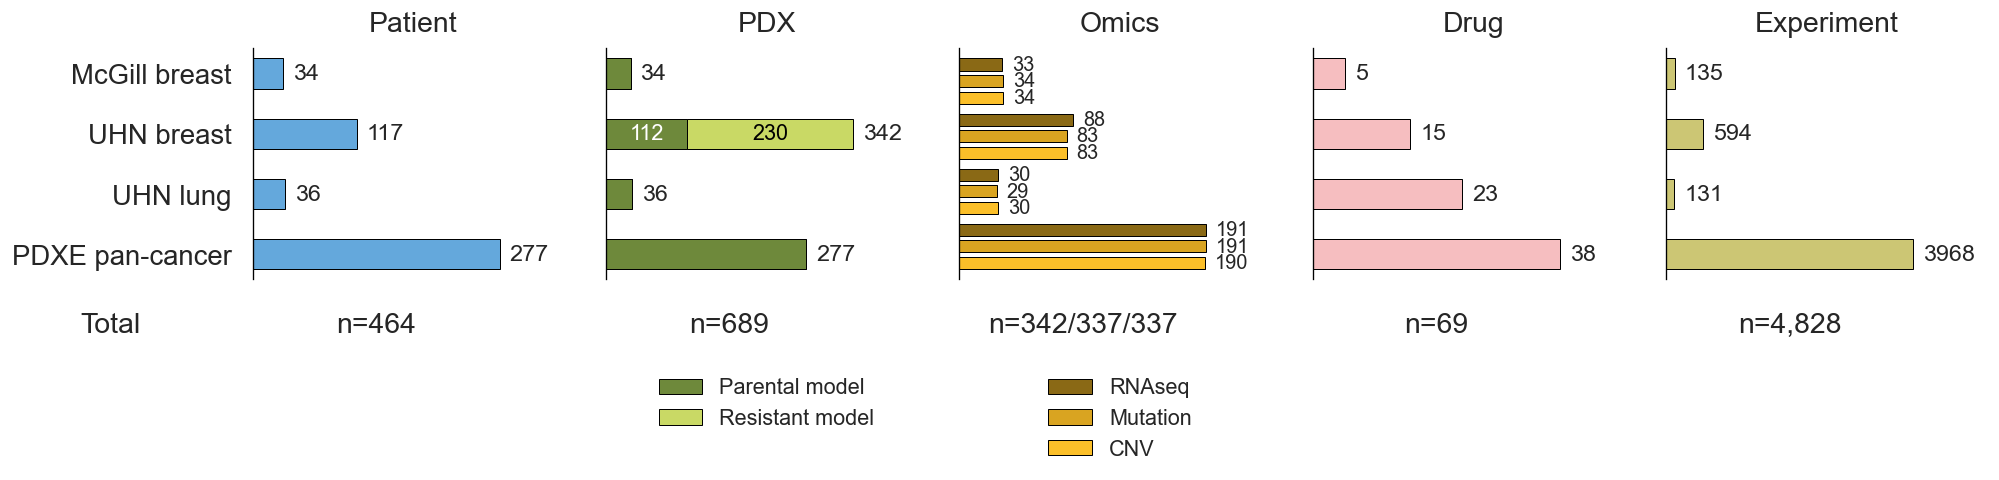

saved ../figures_tables/figures_main/figure1b_summary_counts.png


In [3]:
BAR_COLOR = "#64A8DC"
PARENTAL_COLOR = "#6E893B"
RESISTANT_COLOR = "#C9D965"
OMICS_TYPES = ["RNAseq", "Mutation", "CNV"]
OMICS_COLORS = {
    "RNAseq": "#8A6915",
    "Mutation": "#D9A421",
    "CNV": "#FBBF29",
}
EXPERIMENT_COLORS = {
    "treatment-control experiment": "#8A844D",
    "treatment curves": "#CCC674",
    "control curves": "#EBE482",
}
DRUG_COLOR = "#F6BEC0"
GROUP_BAR_HEIGHT = 0.22
GROUP_BAR_SPACING = 0.30
SINGLE_BAR_HEIGHT = 0.5
XLIM_PAD_FACTOR = 1.3  # every draw_* function sets xlim to (0, max_value * this)


def draw_single_metric(ax, df, metric, color, cohort_order):
    values = df.loc[metric, cohort_order]
    y = np.arange(len(cohort_order))
    ax.barh(y, values, height=SINGLE_BAR_HEIGHT, color=color, edgecolor="black", linewidth=0.6)
    for yi, value in zip(y, values):
        ax.text(value + values.max() * 0.04, yi, f"{int(value)}", va="center", fontsize=14)
    ax.set_yticks(y)
    ax.set_yticklabels(cohort_order)
    ax.invert_yaxis()
    ax.set_xlim(0, values.max() * XLIM_PAD_FACTOR)


def draw_pdx(ax, counts, cohort_order):
    y = np.arange(len(cohort_order))
    parental = counts["parental"]
    resistant = counts["resistant"]
    total = parental + resistant

    ax.barh(y, parental, height=SINGLE_BAR_HEIGHT, color=PARENTAL_COLOR,
            edgecolor="black", linewidth=0.6, label="Parental model")
    ax.barh(y, resistant, left=parental, height=SINGLE_BAR_HEIGHT, color=RESISTANT_COLOR,
            edgecolor="black", linewidth=0.6, label="Resistant model")

    for yi, cohort, p, r, t in zip(y, cohort_order, parental, resistant, total):
        ax.text(t + total.max() * 0.04, yi, f"{int(t)}", va="center", fontsize=14)
        if cohort == "UHN breast":
            if r > 0:
                ax.text(p + r / 2, yi, f"{int(r)}", va="center", ha="center", fontsize=13, color="black")
            if p > 0:
                ax.text(p / 2, yi, f"{int(p)}", va="center", ha="center", fontsize=13, color="white")

    ax.set_yticks(y)
    ax.set_yticklabels(cohort_order)
    ax.invert_yaxis()
    ax.set_xlim(0, total.max() * XLIM_PAD_FACTOR)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.34), ncol=1, frameon=False, fontsize=13)


def draw_grouped(ax, df, metrics, colors, cohort_order):
    y_base = np.arange(len(cohort_order))
    offsets = np.linspace(-1, 1, len(metrics)) * GROUP_BAR_SPACING
    max_value = df.loc[list(metrics), cohort_order].to_numpy().max()

    for (metric, label), offset in zip(metrics.items(), offsets):
        values = df.loc[metric, cohort_order]
        y = y_base + offset
        ax.barh(y, values, height=GROUP_BAR_HEIGHT, color=colors[metric],
                edgecolor="black", linewidth=0.6, label=label)
        for yi, value in zip(y, values):
            ax.text(value + max_value * 0.04, yi, f"{int(value)}", va="center", fontsize=12)

    ax.set_yticks(y_base)
    ax.set_yticklabels(cohort_order)
    ax.invert_yaxis()
    ax.set_xlim(0, max_value * XLIM_PAD_FACTOR)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.34), ncol=1, frameon=False, fontsize=13)


def style_panel(ax, title, show_ylabels):
    ax.set_title(title, fontsize=17, pad=10)
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(0.8)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=False)
    if not show_ylabels:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)


def n_label(df, *metrics):
    """"n=" label from the xlsx's own Total column, comma-formatted, slash-joined
    for panels with more than one metric."""
    parts = [f"{int(df.loc[metric, 'Total']):,}" for metric in metrics]
    return "n=" + "/".join(parts)


df = load_summary()
pdx_counts = load_model_counts()
omics_map = {m: m for m in OMICS_TYPES}

fig, axes = plt.subplots(1, 5, figsize=(17, 5))

draw_single_metric(axes[0], df, "Patient", BAR_COLOR, COHORT_ORDER)
draw_pdx(axes[1], pdx_counts, COHORT_ORDER)
draw_grouped(axes[2], df, omics_map, OMICS_COLORS, COHORT_ORDER)
draw_single_metric(axes[3], df, "Drug", DRUG_COLOR, COHORT_ORDER)
draw_single_metric(
    axes[4], df, "treatment-control experiment",
    EXPERIMENT_COLORS["treatment curves"], COHORT_ORDER,
)

titles = ["Patient", "PDX", "Omics", "Drug", "Experiment"]
for i, (ax, title) in enumerate(zip(axes, titles)):
    style_panel(ax, title, show_ylabels=(i == 0))

plt.tight_layout()

drug_total = int(load_overlap_counts().sum())

n_labels = [
    n_label(df, "Patient"),
    n_label(df, "Model"),
    n_label(df, "RNAseq", "Mutation", "CNV"),
    f"n={drug_total:,}",
    n_label(df, "treatment-control experiment"),
]
# All 5 axes share the same row/height, so a fixed axes-fraction y aligns
# every "n=" label on the same line -- immediately below the bars and
# above each panel's (now pushed further down) legend. Centered on the
# actual bar range (data 0 to max_value), not the padded axes width
# (0 to max_value * XLIM_PAD_FACTOR) -- otherwise the label sits right
# of the bars' visual center, since the padding is one-sided (right only).
N_LABEL_Y = -0.14
N_LABEL_X = 1 / (2 * XLIM_PAD_FACTOR)
for ax, label in zip(axes, n_labels):
    ax.text(N_LABEL_X, N_LABEL_Y, label, transform=ax.transAxes, ha="center", va="top", fontsize=17)

# Single "Total" row header, in the same left column as the dataset
# names and on the same line as the "n=" values.
axes[0].text(
    -0.35, N_LABEL_Y, "Total", transform=axes[0].transAxes,
    ha="right", va="top", fontsize=17,
)

out_name = "figure1b_summary_counts"
fig.savefig(FIGURES_DIR / f"{out_name}.png", bbox_inches="tight")
fig.savefig(FIGURES_DIR / f"{out_name}.pdf", bbox_inches="tight")
plt.show()
print(f"saved {FIGURES_DIR / (out_name + '.png')}")

## Figure 1c -- cancer-type distribution

Exploded pie: PDX models by cancer type, each cancer-type group broken down by contributing dataset.

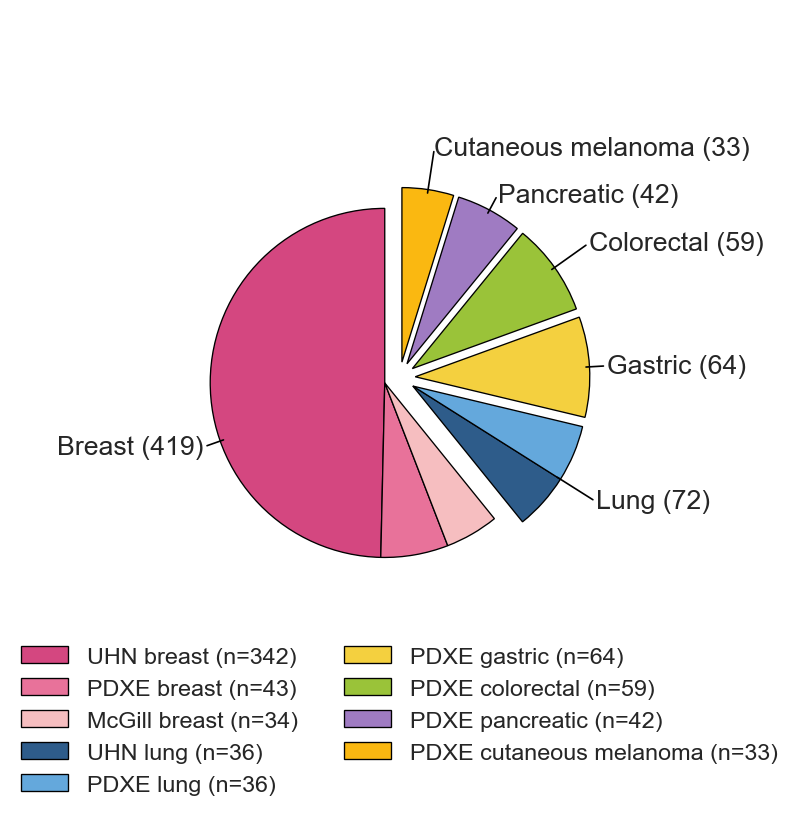

saved ../figures_tables/figures_main/figure1c_cancer_type_distribution.png


In [4]:
EXPLODE_DISTANCE = 0.09

# Ordered so same-cancer-type slices sit adjacent in the pie. Colors echo
# ones already used across the summary panel for visual consistency:
# McGill breast reuses the Drug pink (#F6BEC0), PDXE lung reuses the
# Patient blue (#64A8DC), colorectal reuses the PDX Parental green
# (#6E893B), and melanoma reuses the Omics Mutation gold (#D9A421).
DATASET_ORDER_1C = [
    "UHN breast", "PDXE breast", "McGill breast",
    "UHN lung", "PDXE lung",
    "PDXE gastric",
    "PDXE colorectal",
    "PDXE pancreatic",
    "PDXE cutaneous melanoma",
]
DATASET_COLORS_1C = {
    "UHN breast": "#D44780",
    "PDXE breast": "#E8729A",
    "McGill breast": "#F6BEC0",
    "UHN lung": "#2E5C8A",
    "PDXE lung": "#64A8DC",
    "PDXE gastric": "#F4D03F",
    "PDXE colorectal": "#9AC339",
    "PDXE pancreatic": "#9F7BC2",
    "PDXE cutaneous melanoma": "#FAB811",
}

SHORT_GROUP_LABEL = {
    "Breast Cancer": "Breast",
    "Non-small Cell Lung Carcinoma": "Lung",
    "Gastric Cancer": "Gastric",
    "Colorectal Cancer": "Colorectal",
    "Pancreatic Ductal Carcinoma": "Pancreatic",
    "Cutaneous Melanoma": "Cutaneous melanoma",
}


def load_cancer_type_counts():
    df = pd.read_excel(XLSX_PATH, sheet_name="Sheet2")
    df = df[df["Dataset"] != "Total"]
    return df.set_index("Dataset").loc[DATASET_ORDER_1C]


def plot_cancer_type_pie(df, out_name="figure1c_cancer_type_distribution", out_dir=FIGURES_DIR):
    # Cancer types in first-seen order (DATASET_ORDER_1C already groups same-type
    # datasets together). Every wedge keeps its true proportional angle (the
    # full set still sweeps a complete 360 degrees, no angle is discarded) --
    # each cancer type's whole cluster of wedges is just translated outward,
    # together, along that group's own mid-angle direction, so groups pull
    # apart from a shared center like an exploded pie slice.
    cancer_types = list(dict.fromkeys(df["CancerType"]))
    grand_total = df["Model"].sum()

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-1.35, 2.1)
    ax.set_aspect("equal")
    ax.axis("off")

    wedge_patches = []
    wedge_labels = []
    angle = 90.0  # start at 12 o'clock, sweep counterclockwise, full 360 total

    for group_i, cancer_type in enumerate(cancer_types):
        group_df = df[df["CancerType"] == cancer_type]
        group_span = 360 * (group_df["Model"].sum() / grand_total)
        group_start = angle
        group_end = angle + group_span
        group_mid = np.deg2rad((group_start + group_end) / 2)
        center = (EXPLODE_DISTANCE * np.cos(group_mid), EXPLODE_DISTANCE * np.sin(group_mid))

        sub_angle = group_start
        for dataset, row in group_df.iterrows():
            share = group_span * (row["Model"] / group_df["Model"].sum())
            theta1, theta2 = sub_angle, sub_angle + share

            wedge = Wedge(
                center, 1.0, theta1, theta2,
                facecolor=DATASET_COLORS_1C[dataset], edgecolor="black", linewidth=0.8,
            )
            ax.add_patch(wedge)
            wedge_patches.append(wedge)
            wedge_labels.append(f"{dataset} (n={int(row['Model'])})")

            sub_angle = theta2

        # Callout line + label at the group's own mid-angle, naming the
        # cancer type and its total model count across all its datasets.
        # Radius is staggered (near/far) between consecutive groups so
        # labels on closely-spaced small slices don't collide.
        line_radius = 1.08 if group_i % 2 == 0 else 1.22
        line_start = (center[0] + 0.98 * np.cos(group_mid), center[1] + 0.98 * np.sin(group_mid))
        line_end = (center[0] + line_radius * np.cos(group_mid), center[1] + line_radius * np.sin(group_mid))
        ax.plot(
            [line_start[0], line_end[0]], [line_start[1], line_end[1]],
            color="black", linewidth=1,
        )
        group_total = int(group_df["Model"].sum())
        short_type = SHORT_GROUP_LABEL[cancer_type]
        text_ha = "left" if np.cos(group_mid) >= 0 else "right"
        ax.text(
            line_end[0] + 0.02 * np.cos(group_mid), line_end[1] + 0.02 * np.sin(group_mid),
            f"{short_type} ({group_total})",
            ha=text_ha, va="center", fontsize=16,
        )

        angle = group_end

    ax.legend(
        wedge_patches, wedge_labels, loc="upper center", bbox_to_anchor=(0.5, -0.02),
        ncol=2, frameon=False, fontsize=14,
    )

    plt.tight_layout()
    fig.savefig(out_dir / f"{out_name}.png", bbox_inches="tight")
    fig.savefig(out_dir / f"{out_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"saved {out_dir / (out_name + '.png')}")


plot_cancer_type_pie(load_cancer_type_counts())

## Figure 1d -- shared-drug dot-matrix

UpSet-style dot-matrix of the drugs shared across more than one dataset (drug_dataset_overlap.csv).

          drug  n_datasets                                datasets
0   Paclitaxel           4  mcgill_breast,pdxe,uhn_breast,uhn_lung
1  Gemcitabine           3             mcgill_breast,pdxe,uhn_lung
2       BGJ398           2                           pdxe,uhn_lung
3       BKM120           2                           pdxe,uhn_lung
4  Carboplatin           2                mcgill_breast,uhn_breast
5    Cisplatin           2                  mcgill_breast,uhn_lung
6    cetuximab           2                           pdxe,uhn_lung
7    erlotinib           2                           pdxe,uhn_lung
8  Palbociclib           2                     uhn_breast,uhn_lung


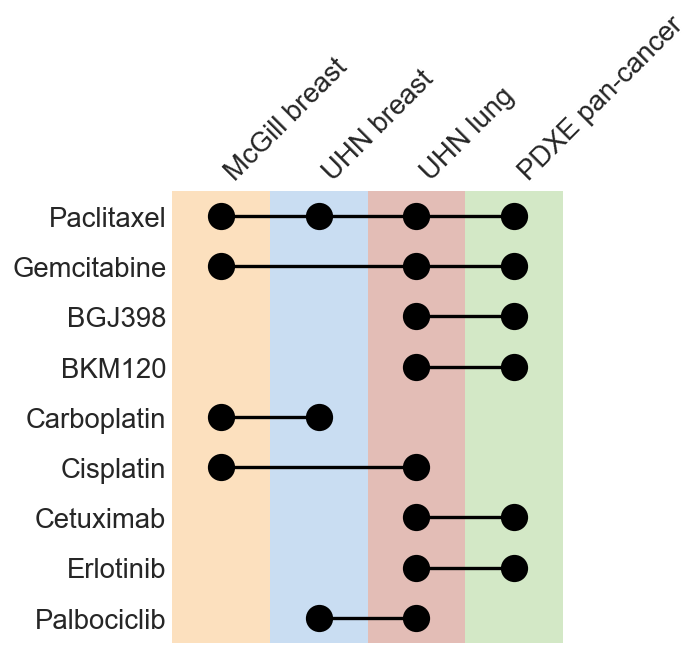

saved ../figures_tables/figures_main/figure1d_shared_drugs.png


In [5]:
DATASET_ORDER_1D = ["mcgill_breast", "uhn_breast", "uhn_lung", "pdxe"]
DATASET_LABELS_1D = {
    "mcgill_breast": "McGill breast",
    "uhn_breast": "UHN breast",
    "uhn_lung": "UHN lung",
    "pdxe": "PDXE pan-cancer",
}
DOT_COLOR = "black"
COLUMN_SHADE_COLORS_1D = {
    "mcgill_breast": "#FCE0BE",
    "uhn_breast": "#C9DDF2",
    "uhn_lung": "#E3BDB6",
    "pdxe": "#D3E8C6",
}


def load_shared_drugs():
    df = pd.read_csv(OVERLAP_CSV_PATH)
    df["dataset_list"] = df["datasets"].str.split(",")
    df["n_datasets"] = df["dataset_list"].apply(len)
    shared = df[df["n_datasets"] > 1].copy()
    shared = shared.sort_values(
        ["n_datasets", "drug"], ascending=[False, True], key=lambda s: s.str.lower() if s.name == "drug" else s,
    ).reset_index(drop=True)

    # Keep Cisplatin next to Carboplatin (both platinum agents) rather than
    # wherever plain alphabetical order would put it.
    drugs = shared["drug"].tolist()
    if "Cisplatin" in drugs and "Carboplatin" in drugs:
        drugs.remove("Cisplatin")
        drugs.insert(drugs.index("Carboplatin") + 1, "Cisplatin")
        shared = shared.set_index("drug").loc[drugs].reset_index()

    return shared


def plot_drug_dot_matrix(shared, out_name="figure1d_shared_drugs", out_dir=FIGURES_DIR):
    n_rows = len(shared)
    n_cols = len(DATASET_ORDER_1D)

    fig, ax = plt.subplots(figsize=(6, (0.55 * n_rows + 1.5) * 0.9))

    for col_i, ds in enumerate(DATASET_ORDER_1D):
        ax.axvspan(col_i - 0.5, col_i + 0.5, color=COLUMN_SHADE_COLORS_1D[ds], linewidth=0, zorder=0)

    for row_i, row in shared.iterrows():
        present = set(row["dataset_list"])
        member_x = [col_i for col_i, ds in enumerate(DATASET_ORDER_1D) if ds in present]

        # connecting line + solid dots across the columns this drug is in
        if len(member_x) > 1:
            ax.plot([min(member_x), max(member_x)], [row_i, row_i], color=DOT_COLOR, linewidth=2, zorder=2)
        ax.scatter(member_x, [row_i] * len(member_x), s=220, color=DOT_COLOR, zorder=3)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([DATASET_LABELS_1D[d] for d in DATASET_ORDER_1D], rotation=45, ha="left")
    ax.xaxis.tick_top()
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([d[:1].upper() + d[1:] for d in shared["drug"]])
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

    plt.tight_layout()
    fig.savefig(out_dir / f"{out_name}.png", bbox_inches="tight")
    fig.savefig(out_dir / f"{out_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"saved {out_dir / (out_name + '.png')}")


shared_drugs = load_shared_drugs()
print(shared_drugs[["drug", "n_datasets", "datasets"]])
plot_drug_dot_matrix(shared_drugs)

## Figure 1e -- resource comparison

Membership-style comparison of XevaDB vs. four existing PDX-related resources, from `database_summary.xlsx` (hand-curated external reference data, separate from the pipeline-generated `dataset_summary.xlsx`).

                                   Model metadata Molecular profiles  \
PDX Resource                                                           
PDX Finder / PDCM Finder (retired)            Yes                Yes   
EurOPDX                                       Yes                Yes   
PDMR                                          Yes                Yes   
PDXNet                                        Yes                Yes   
XevaDB                                        Yes                Yes   

                                   Drug response Longitudinal tumour volume  \
PDX Resource                                                                  
PDX Finder / PDCM Finder (retired)       Limited                         No   
EurOPDX                                  Limited                    Limited   
PDMR                                          No                    Limited   
PDXNet                                   Limited                    Limited   
XevaDB               

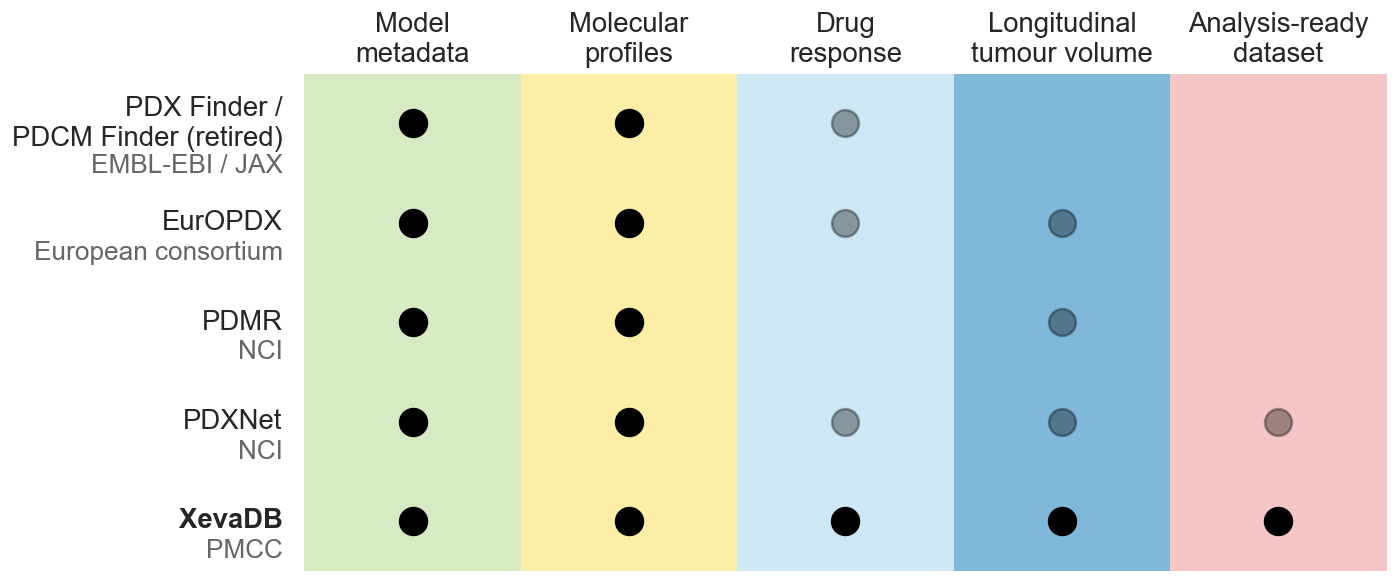

saved ../figures_tables/figures_main/figure1e_resource_comparison.png


In [6]:
RESOURCE_COL = "PDX Resource"
EXCLUDE_COLS_1E = ["Portal website", "Organization"]
BOLD_RESOURCE = "XevaDB"

DOT_MARKER = "o"
PARTIAL_ALPHA = 0.35
DOT_SIZE = 260
LABEL_WRAP_WIDTH = 11
# Explicit line breaks for labels where generic wrapping doesn't give the
# desired split.
LABEL_OVERRIDES = {
    "Longitudinal tumour volume": "Longitudinal\ntumour volume",
    "Analysis-ready dataset": "Analysis-ready\ndataset",
}
# Short forms for the figure's row-label subtitle -- distinct from the fuller
# text in Sheet3's "Organization" column, which is too long to fit under a
# resource name without repeating the header-collision problem long labels
# already caused once. Keyed by exact "PDX Resource" cell text -- a row rename
# needs a matching update here (same tradeoff as LABEL_OVERRIDES above).
ORG_SHORT_LABELS = {
    "PDX Finder / PDCM Finder (retired)": "EMBL-EBI / JAX",
    "EurOPDX": "European consortium",
    "PDMR": "NCI",
    "PDXNet": "NCI",
    "XevaDB": "PMCC",
}
# Line breaks for resource names too long to sit on one line -- same
# rationale/tradeoff as LABEL_OVERRIDES above (keyed by exact "PDX Resource"
# cell text; a rename needs a matching update here).
RESOURCE_LABEL_OVERRIDES = {
    "PDX Finder / PDCM Finder (retired)": "PDX Finder /\nPDCM Finder (retired)",
}
COLUMN_SHADE_COLORS_1E = {
    "Model metadata": "#D6EAC4",
    "Molecular profiles": "#FCEEA6",
    "Drug response": "#CDE7F4",
    "Longitudinal tumour volume": "#7FB8D9",
    "Analysis-ready dataset": "#F5C6C6",
}


def load_resource_matrix():
    df = pd.read_excel(DATABASE_XLSX_PATH, sheet_name="Sheet1")
    df = df.set_index(RESOURCE_COL)
    df = df.drop(columns=EXCLUDE_COLS_1E)
    return df


def plot_resource_matrix(df, out_name="figure1e_resource_comparison", out_dir=FIGURES_DIR):
    resources = df.index.tolist()
    capabilities = df.columns.tolist()
    n_rows = len(resources)
    n_cols = len(capabilities)

    fig, ax = plt.subplots(figsize=(2.0 * n_cols + 2, 0.6 * n_rows + 2.2))

    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))

    for col_i, capability in enumerate(capabilities):
        shade = COLUMN_SHADE_COLORS_1E.get(capability)
        if shade is not None:
            ax.axvspan(col_i - 0.5, col_i + 0.5, color=shade, linewidth=0, zorder=0)

    for row_i, resource in enumerate(resources):
        for col_i, capability in enumerate(capabilities):
            value = str(df.loc[resource, capability]).strip().lower()
            if value == "yes":
                ax.scatter(col_i, row_i, s=DOT_SIZE, marker=DOT_MARKER, color="black", zorder=2)
            elif value == "limited":
                ax.scatter(
                    col_i, row_i, s=DOT_SIZE, marker=DOT_MARKER, color="black",
                    alpha=PARTIAL_ALPHA, zorder=2,
                )
            # "no" -> nothing drawn

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    wrapped_capabilities = [
        LABEL_OVERRIDES.get(c) or "\n".join(textwrap.wrap(c, width=LABEL_WRAP_WIDTH, break_long_words=False))
        for c in capabilities
    ]
    ax.set_xticklabels(wrapped_capabilities, rotation=0, ha="center")
    ax.xaxis.tick_top()

    # Two-tier row labels (resource name + smaller/greyed organization
    # subtitle) instead of plain yticklabels, since a single Text artist
    # can't mix font sizes across its lines.
    ax.set_yticklabels([])
    for row_i, resource in enumerate(resources):
        org = ORG_SHORT_LABELS.get(resource)
        display_name = RESOURCE_LABEL_OVERRIDES.get(resource, resource)
        two_line_name = "\n" in display_name
        # The name's vertical CENTER always sits on row_i, exactly where its
        # dots are -- that alignment takes priority. The org subtitle just
        # hangs below it, pushed further down when the name itself is 2
        # lines tall so it clears the name's bottom edge.
        name_y = row_i
        org_y = row_i + (0.43 if two_line_name else 0.30) if org else None
        ax.text(
            -0.6, name_y, display_name, transform=ax.transData, ha="right", va="center",
            fontsize=plt.rcParams["ytick.labelsize"],
            fontweight="bold" if resource == BOLD_RESOURCE else "normal",
            clip_on=False,
        )
        if org:
            ax.text(
                -0.6, org_y, org, transform=ax.transData, ha="right", va="center",
                fontsize=plt.rcParams["ytick.labelsize"] * 0.95, color="#666666",
                clip_on=False,
            )

    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    fig.savefig(out_dir / f"{out_name}.png", bbox_inches="tight")
    fig.savefig(out_dir / f"{out_name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"saved {out_dir / (out_name + '.png')}")


resource_matrix = load_resource_matrix()
print(resource_matrix)
plot_resource_matrix(resource_matrix)